**PRACTICAL 1**

**Q) Write a Program for Data Frames and Basic Data Pre-processing.**

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving Iris.csv to Iris.csv


In [ ]:

import pandas as pd

def read_data(file_path, file_format):
    if file_format.lower() == 'json':
        df = pd.read_json(file_path)
    elif file_format.lower() == 'html':
        df = pd.read_html(file_path)[0]
    elif file_format.lower() == 'xml':
        df = pd.read_xml(file_path)
    elif file_format.lower() == 'csv':
        df = pd.read_csv(file_path)
    else:
        raise ValueError("Unsupported file format. Please choose from JSON, HTML, XML, or CSV.")
    return df

def handle_missing_data(df):
    missing_values = df.isnull().sum()
    if missing_values.sum() > 0:
        print("Missing values found:")
        print(missing_values)
    else:
        print("No missing values found.")

def handle_outliers(df):
    pass

file_path = '/content/Iris.csv'
file_format = 'csv'

data = read_data(file_path, file_format)

handle_missing_data(data)

handle_outliers(data)



No missing values found.


**PRACTICAL 2**

**CSV DATA FILTER AND SORTING.**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Iris (1).csv to Iris (1).csv


In [ ]:
import pandas as pd
df=pd.read_csv('/content/Iris (1).csv')
# Convert all relevant columns to numeric, coercing errors to NaN
df['SepalLengthCm'] = pd.to_numeric(df['SepalLengthCm'], errors='coerce')
df['SepalWidthCm'] = pd.to_numeric(df['SepalWidthCm'], errors='coerce')
df['PetalLengthCm'] = pd.to_numeric(df['PetalLengthCm'], errors='coerce')
df['PetalWidthCm'] = pd.to_numeric(df['PetalWidthCm'], errors='coerce')

df.describe()
filter_df=df[df['SepalLengthCm']>5]
filter_df
filter_df=df[df['SepalWidthCm']<5]
filter_df
sort_df=df.sort_values(by='SepalLengthCm')
sort_df
group_df=df.groupby('Species')
group_df.mean()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
Species,,,,,
Iris-setosa,25.5,4.995556,3.430000,1.454348,0.242222
Iris-versicolor,75.5,5.925581,2.764286,4.236957,1.323913
Iris-virginica,125.5,6.631818,2.979070,5.516279,2.028571


**PRACTICAL 3**

**Machine Learning Libraries.**

In [ ]:
# 1. Pandas: For data manipulation and analysis
import pandas as pd
print(f"Pandas version: {pd.__version__}")

Pandas version: 2.2.2


In [ ]:
# 2. NumPy: For numerical computing with arrays and matrices
import numpy as np
print(f"NumPy version: {np.__version__}")

NumPy version: 2.0.2


In [ ]:
# 3. Matplotlib: For creating static, interactive, and animated visualizations
import matplotlib
print(f"Matplotlib version: {matplotlib.__version__}")

Matplotlib version: 3.10.0


In [ ]:
# 4. Seaborn: For statistical data visualization, built on Matplotlib
import seaborn as sns
print(f"Seaborn version: {sns.__version__}")

Seaborn version: 0.13.2


In [ ]:
# 5. Scikit-learn: For traditional machine learning algorithms
import sklearn
print(f"Scikit-learn version: {sklearn.__version__}")

Scikit-learn version: 1.6.1


In [ ]:
# 6. SciPy: For scientific and technical computing
import scipy
print(f"SciPy version: {scipy.__version__}")

SciPy version: 1.16.3


In [ ]:
# 7. TensorFlow: An open-source machine learning platform (deep learning)
import tensorflow as tf
print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.19.0


In [ ]:
# 8. PyTorch: An open-source machine learning library (deep learning)
import torch
print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.8.0+cu126


In [ ]:
# 9. Keras: A high-level neural networks API (often runs on TensorFlow)
import keras
print(f"Keras version: {keras.__version__}")

Keras version: 3.10.0


In [ ]:
# 10. XGBoost: For optimized distributed gradient boosting
import xgboost as xgb
print(f"XGBoost version: {xgb.__version__}")

XGBoost version: 3.1.1


**PRACTICAL 4**

**Feature Scaling and Dummification.**

1.Wine Dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving wine.csv to wine.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [ ]:
df = pd.read_csv("wine.csv")
df

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [ ]:
df1 = pd.read_csv("wine.csv",  usecols=[0,1,2], skiprows=1)
df1.columns = ['classlabel', 'Alcohol', 'Malic Acid']
print("Original DataFrame:")
df1

Original DataFrame:


,classlabel,Alcohol,Malic Acid
0,1,13.20,1.78
1,1,13.16,2.36
2,1,14.37,1.95
3,1,13.24,2.59
4,1,14.20,1.76
...,...,...,...
172,3,13.71,5.65
173,3,13.40,3.91
174,3,13.27,4.28
175,3,13.17,2.59


In [ ]:
scaling= MinMaxScaler()
scaled_value = scaling.fit_transform(df1[['Alcohol', 'Malic Acid']])
df1[['Alcohol', 'Malic Acid']] = scaled_value
print("\n Dataframe after MinMax Scaling")
df1


 Dataframe after MinMax Scaling


,classlabel,Alcohol,Malic Acid
0,1,0.571053,0.205534
1,1,0.560526,0.320158
2,1,0.878947,0.239130
3,1,0.581579,0.365613
4,1,0.834211,0.201581
...,...,...,...
172,3,0.705263,0.970356
173,3,0.623684,0.626482
174,3,0.589474,0.699605
175,3,0.563158,0.365613


In [ ]:
scaling = StandardScaler()
scaled_standardvalue = scaling.fit_transform(df1[['Alcohol', 'Malic Acid']])
df1[['Alcohol', 'Malic Acid']] = scaled_standardvalue
print("\ Dataframe after Standard Scaling")
df1

\ Dataframe after Standard Scaling


<>:4: SyntaxWarning: invalid escape sequence '\ '
<>:4: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipython-input-817344507.py:4: SyntaxWarning: invalid escape sequence '\ '
  print("\ Dataframe after Standard Scaling")


,classlabel,Alcohol,Malic Acid
0,1,0.255824,-0.501624
1,1,0.206229,0.018020
2,1,1.706501,-0.349315
3,1,0.305420,0.224086
4,1,1.495719,-0.519543
...,...,...,...
172,3,0.888171,2.965658
173,3,0.503803,1.406725
174,3,0.342617,1.738222
175,3,0.218628,0.224086


2.Iris Dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Iris.csv to Iris.csv


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

In [ ]:
iris = pd.read_csv("Iris.csv")
iris

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Virginica
146,6.3,2.5,5.0,1.9,Virginica
147,6.5,3.0,5.2,2.0,Virginica
148,6.2,3.4,5.4,2.3,Virginica


In [ ]:
le =  LabelEncoder()
iris['code']= le.fit_transform(iris.variety)
iris

,sepal.length,sepal.width,petal.length,petal.width,variety,code
0,5.1,3.5,1.4,0.2,Setosa,0
1,4.9,3.0,1.4,0.2,Setosa,0
2,4.7,3.2,1.3,0.2,Setosa,0
3,4.6,3.1,1.5,0.2,Setosa,0
4,5.0,3.6,1.4,0.2,Setosa,0
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Virginica,2
146,6.3,2.5,5.0,1.9,Virginica,2
147,6.5,3.0,5.2,2.0,Virginica,2
148,6.2,3.4,5.4,2.3,Virginica,2


**PRACTICAL 5**

**Linear Regression (Diabetes Dataset).**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving diabetes.csv to diabetes.csv



Coefficients are:
 [ -59.73800266 -215.61743016  599.93653427  291.96204216 -829.65803548
  544.64726088  164.85115861  224.22784698  768.94812134   70.84955215]

Intercept: 152.89017197328025
Variance score: 0.41603976183363156
Mean squared error: 2962.95


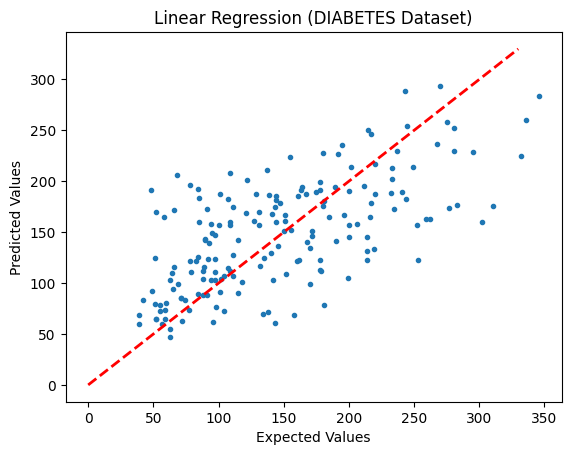

In [ ]:
# Import Dependencies
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets, linear_model, metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns

# Load the diabetes dataset
diabetes = datasets.load_diabetes()

# X - feature vectors
# y - Target values
X = diabetes.data
y = diabetes.target



# Splitting X and y into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=1
)

# Create linear regression object
lin_reg = linear_model.LinearRegression()

# Train the model using train data
lin_reg.fit(X_train, y_train)

# Predict values for X_test data
predicted = lin_reg.predict(X_test)

# Regression coefficients
print("\nCoefficients are:\n", lin_reg.coef_)

# Intercept
print("\nIntercept:", lin_reg.intercept_)

# Variance score (R² Score)
print("Variance score:", lin_reg.score(X_test, y_test))

# Mean Squared Error
print("Mean squared error: %.2f"
      % mean_squared_error(y_test, predicted))

# Original data of X_test
expected = y_test

# Plot a graph for expected and predicted values
plt.title("Linear Regression (DIABETES Dataset)")
plt.scatter(expected, predicted, marker='.', s=36)
plt.plot(
    np.linspace(0, 330, 100),
    np.linspace(0, 330, 100),
    '--',
    linewidth=2,
    color='red'
)
plt.xlabel("Expected Values")
plt.ylabel("Predicted Values")
plt.show()


**PRACTICAL 6**

**Logistic Regression (Iris Dataset).**

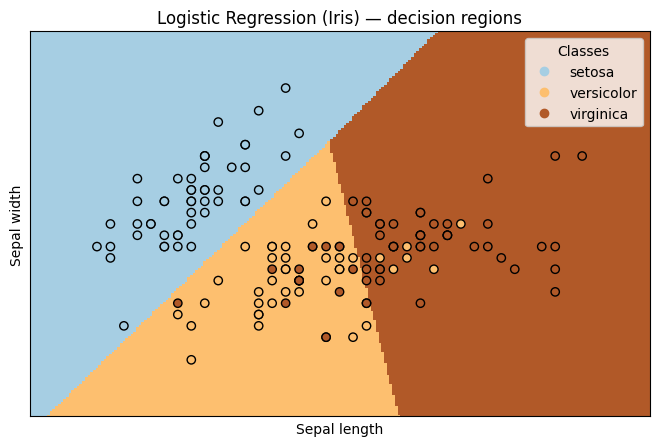

In [ ]:
# logistic_iris_decision_boundary.py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn import datasets

# Load iris dataset
iris = datasets.load_iris()
X = iris.data[:, :2]   # we only take the first two features: sepal length, sepal width
y = iris.target

# Create and fit logistic regression classifier
# Large C to approximate hard margins like in many demo notebooks
logreg = LogisticRegression(C=1e5, max_iter=200)
logreg.fit(X, y)

# Plot the decision boundary. For that, we assign a color to each point in the mesh [x_min, x_max]x[y_min, y_max].
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

h = 0.02  # step size in the mesh
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Predict for each point in the mesh
Z = logreg.predict(np.c_[xx.ravel(), yy.ravel()])

# Put the result into a color plot
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 5))
plt.pcolormesh(xx, yy, Z, cmap=plt.cm.Paired, shading='auto')

# Plot also the training points
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.Paired)
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.xticks(())
plt.yticks(())
plt.title('Logistic Regression (Iris) — decision regions')

# Optional: legend showing class names
handles, _ = scatter.legend_elements()
plt.legend(handles, iris.target_names, title="Classes", loc='upper right')

plt.show()

**PRACTICAL 7**

**Conduct a Hypothesis test using appropriate statistical tests (e.g., t-test,chi-square test).**

T-statistic: 5.422
P-value: 0.0002
Reject the null hypothesis (significant difference).


/tmp/ipython-input-3616792722.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([group_1, group_2], labels=['Group 1', 'Group 2'])


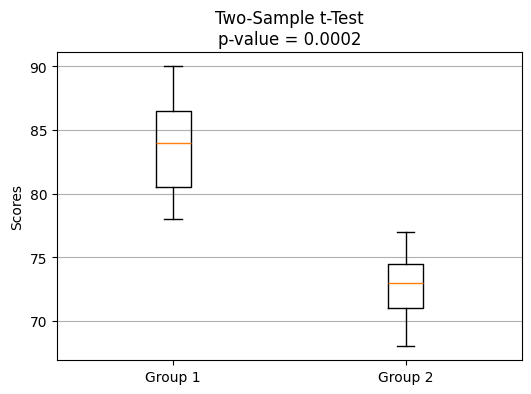

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# Sample data
group_1 = np.array([78, 82, 85, 88, 90, 84, 79])
group_2 = np.array([72, 75, 70, 68, 74, 77, 73])

# Two-sample t-test (Welch's t-test recommended)
t_stat, p_value = ttest_ind(group_1, group_2, equal_var=False)

print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.4f}")

# Decision
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis (significant difference).")
else:
    print("Fail to reject the null hypothesis (no significant difference).")

# Boxplot visualization
plt.figure(figsize=(6,4))
plt.boxplot([group_1, group_2], labels=['Group 1', 'Group 2'])
plt.ylabel('Scores')
plt.title(f'Two-Sample t-Test\np-value = {p_value:.4f}')
plt.grid(axis='y')
plt.show()


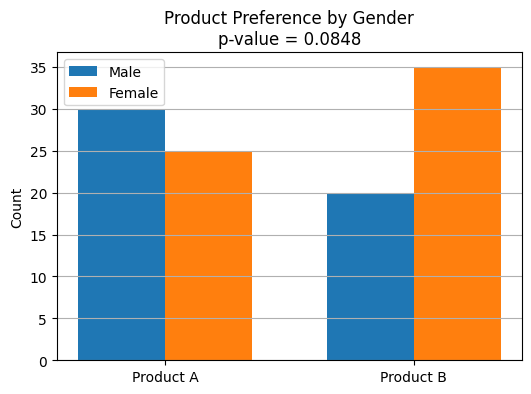

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# Contingency table
data = np.array([
    [30, 20],   # Male
    [25, 35]    # Female
])

labels = ['Product A', 'Product B']

# Chi-square test
chi2, p, dof, expected = chi2_contingency(data)

# Bar plot
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(6,4))
plt.bar(x - width/2, data[0], width, label='Male')
plt.bar(x + width/2, data[1], width, label='Female')

plt.xticks(x, labels)
plt.ylabel('Count')
plt.title(f'Product Preference by Gender\np-value = {p:.4f}')
plt.legend()
plt.grid(axis='y')

plt.show()


**PRACTICAL 9**

**Q)Logistic Regression and Decision Tree.**

Part I: Build a logistic regression model to predict a binary outcome.Evaluate the model's performance using classification metrics (e.g., accuracy,precision,recall).

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

In [ ]:
df=pd.read_csv("/content/Iris.csv")
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [ ]:
df1=df[df['Species'] !=2]
df1

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [ ]:
df=df[df['Species'] !=2]
x=df.drop('Species',axis=1)
y=df['Species']

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=2,random_state=42)
logistic_model=LogisticRegression()
logistic_model.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
y_pred_logistic=logistic_model.predict(x_test)
print("Accuracy:",accuracy_score(y_test,y_pred_logistic))
print("\nClassification Report")
print(classification_report(y_test,y_pred_logistic))

Accuracy: 1.0

Classification Report
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         1
Iris-versicolor       1.00      1.00      1.00         1

       accuracy                           1.00         2
      macro avg       1.00      1.00      1.00         2
   weighted avg       1.00      1.00      1.00         2



Part II: Construct a decision tree model and interpret the decision rules for classification.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
model=DecisionTreeClassifier()
model.fit(x_train,y_train)
y_pred_tree=model.predict(x_test)
y_pred_tree

array(['Iris-versicolor', 'Iris-setosa', 'Iris-virginica',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-setosa',
       'Iris-versicolor', 'Iris-virginica', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-virginica', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-versicolor', 'Iris-virginica',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-virginica',
       'Iris-setosa', 'Iris-virginica', 'Iris-setosa', 'Iris-virginica',
       'Iris-virginica', 'Iris-virginica', 'Iris-virginica',
       'Iris-virginica', 'Iris-setosa', 'Iris-setosa'], dtype=object)

In [ ]:
print("\nDecision Tree Metrics")
print("Accuracy:",accuracy_score(y_test,y_pred_tree))
print("\nClassification Report")
print(classification_report(y_test,y_pred_tree))


Decision Tree Metrics
Accuracy: 1.0

Classification Report
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



**PRACTICAL 10**

**K-Means Clustering.**

**Apply the K-Means algorithm to group similar data points into clusters.Determine the optimal number of clusters using elbow method or silhouette analysis.Visualize the clustering results and analyze the cluster characteristics.**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

In [ ]:
X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=42)
inertia=[]
k_range=range(1,11)

In [ ]:
inertia = [] # Clear inertia list before populating
for k in k_range:
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

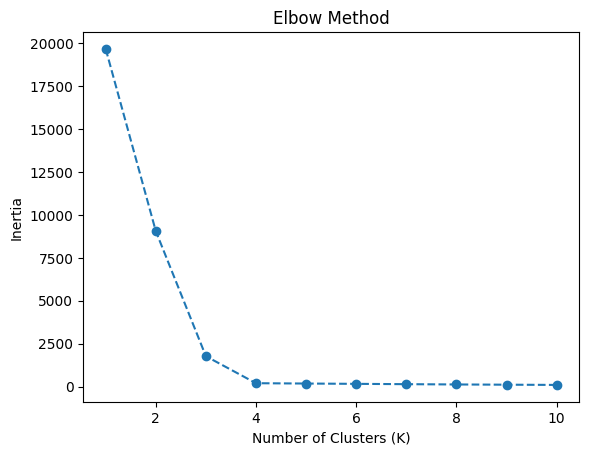

In [ ]:
plt.plot(k_range,inertia, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [ ]:
kmeans=KMeans(n_clusters=4,random_state=42,n_init=10)
y_kmeans=kmeans.fit_predict(X)

In [ ]:
plt.scatter(X[:,0],X[:,1],c=y_kmeans,cmap='viridis',edgecolors='k')
plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],s=250,marker='X',c='red',label='Centroids')
plt.title('K-Means Clustering')
plt.le

**PRACTICAL 11**

**PRINCIPAL COMPONENT ANALYSIS (PCA).**

**Perform PCA on a dataset to reduce dimensionality.Evaluate the explained variance and select the appropriate number of principal components.Visualize the data in the reduced-dimensional space.**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

In [ ]:
data=load_iris()
X=data.data
y=data.target

In [ ]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

pca=PCA()
X_pca=pca.fit_transform(X_scaled)

In [ ]:
explained_variance=pca.explained_variance_ratio_
cumulative_variance=np.cumsum(explained_variance)

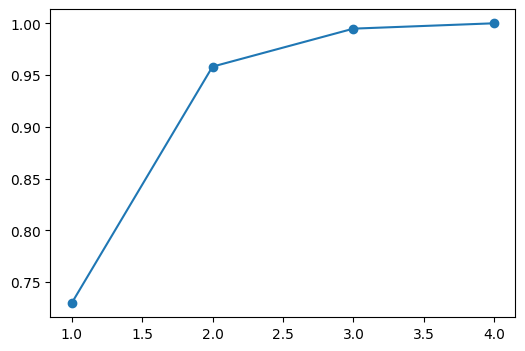

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(range(1, len(explained_variance)+1), cumulative_variance, marker='o', linestyle='-')

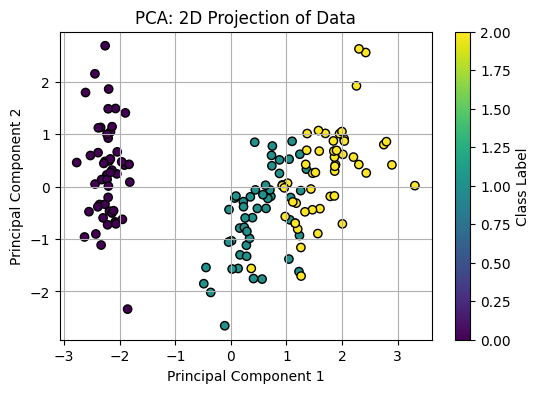

In [ ]:
pca_2d=PCA(n_components=2)
X_pca_2d=pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(6,4))
plt.scatter(X_pca_2d[:,0], X_pca_2d[:,1], c=y, cmap='viridis',edgecolor='k')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA: 2D Projection of Data')
plt.colorbar(label='Class Label')
plt.grid(True)
plt.show()